## R & D - Environment - V 2.0

**Goal**: Use max tool life, minimize replacements (i.e. only once) and maximize *replacement time* till just before end of life

**Rewards**:
- Each time-step of 'useful' use: Forward_Reward += 1
- Each time-step after threshold Forward_Reward -= 1
- Replacement is a Cost = 10
- Reward = Forward_Reward - Replacement_Cost

**Termination**:
- **Only** when episode ends i.e. time-step >= max_records
- Note: No termination crossing RUL threshold


In [177]:
EPISODES = 100
ALGO = 'A2C'
TENSOR_BOARD = True
PRETRAINED_MODEL = False 

import numpy as np
import gymnasium as gym
from gymnasium import spaces

LAMBDA = 0.01
RANDOM_TOOL_START_OF_LIFE = 0.10 # 10% from the start
NO_ACTION = 0
REPLACE = 1

# Information arrays 
a_time = []

a_cost = []
a_replacements = []
a_time_since_last_replacement = []

In [178]:
class MTENV(gym.Env):

    def __init__(self, max_records=0, env_type = '', rul_threshold=0.0, R1=1, R2=-10, R3=-4):
        print(f'\n -- V.2.0: {env_type}. Records {max_records}. RUL threshold {rul_threshold:4.3f}')

        # Initialize
        self.R1 = R1
        self.R2 = R2
        self.R3 = R3
        self.cummulative_rewards = 0.0
        
        self.a_rewards = []
        self.a_actions = []
        self.a_action_recommended = []
        self.a_rul = []

        self.df = None
        self.current_time_step = 0
        self.max_records = max_records
        self.maintenance_cost = 0.0
        self.replacement_events = 0
        self.time_since_last_replacement = 0
        self.rul_threshold = rul_threshold
        
        high = np.array(6*[1.0], dtype=np.float32)
        low = np.array(6*[-1.0], dtype=np.float32)
        self.observation_space = spaces.Box(low, high, dtype=np.float32)
        self.action_space = spaces.Discrete(2)

    ## Add tool wear data-set
    def tool_wear_data(self, df):
        self.df = df
        self.max_records = len(df.index)
        print(f'\n - Milling tool environment: Tool wear data updated: {self.max_records}')
        
    def _get_observation(self):
        if (self.df is not None):
            obs_values = np.array([
                self.df.loc[self.current_time_step, 'force_x'],
                self.df.loc[self.current_time_step, 'force_y'],
                self.df.loc[self.current_time_step, 'force_z'],
                self.df.loc[self.current_time_step, 'vibration_x'],
                self.df.loc[self.current_time_step, 'vibration_y'],
                self.df.loc[self.current_time_step, 'vibration_z']
            ], dtype=np.float32)
        else:
            obs_values = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
        
        observation = obs_values.flatten()
        return observation

    def _get_auxilliary_info(self):
        if (self.df is not None):
            recommended_action = int(self.df.loc[self.current_time_step, 'ACTION_CODE'])
            rul = float(self.df.loc[self.current_time_step, 'RUL'])
        else:
            recommended_action = 0
            rul = 0.0

        return recommended_action, rul
            
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.a_rewards = []
        self.a_actions = []
        self.a_action_recommended = []
        self.a_rul = [] 
        
        # Choose the tool wear at a random time (spatial) location from a uniformly random distribution
        # self.current_time_step = np.random.randint(0, int(RANDOM_TOOL_START_OF_LIFE * self.max_records), 1, dtype=int)
        self.current_time_step = 0
        self.cummulative_rewards = 0.0
        
        observation = self._get_observation()
        info = {'reset':'Reset'}
        return observation, info

    ## Step
    def step(self, action):
        terminated = False
        reward = 0.0
        info = {'Step':'-'}
        # Get auxilliary info: current RUL reading (note this is NOT part of the observation) and the expert's recommended action
        recommended_action, self.rul = self._get_auxilliary_info()
        self.maintenance_cost = 0.0
        
        if self.current_time_step >= self.max_records:
            terminated = done = True
        elif self.rul > self.rul_threshold:
            reward += self.current_time_step*self.R1
        elif self.rul <= self.rul_threshold:
            reward += self.current_time_step*self.R2
        elif action == REPLACE:
            reward += self.current_time_step*self.R3

        
        self.cummulative_rewards = self.cummulative_rewards + reward
            
        # Information arrays 
        self.a_rewards.append(reward)
        self.a_actions.append(action)
        self.a_action_recommended.append(recommended_action)
        self.a_rul.append(self.rul)
        
        a_time.append(self.current_time_step)
        
        # Action taken, reward set for that action, now take in next observation
        observation = self._get_observation()

        if self.current_time_step < self.max_records: 
            self.current_time_step += 1

        if self.rul > self.rul_threshold:
            print('Action: {0:2d} | RUL: {1:>8.2f} | Reward: {2:>12.3f} -- CR: {3:>12.3f}'.format(action, self.rul, reward, self.cummulative_rewards) )
        else:
            print(f'*** TERMINATED: {self.rul:3.2f} ***')
        
        return observation, reward, terminated, False, info

In [179]:
import warnings
from tqdm import tqdm # Progress bar
from datetime import datetime
warnings.filterwarnings('ignore')

# General libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

# RL libraries
import gymnasium as gym
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3 import PPO, A2C
from stable_baselines3.ppo import MlpPolicy
from torch.utils.tensorboard import SummaryWriter

# Custom libraries
# import MT_environment
# from MT_environment import MillingTool_Env_PHM,  MillingTool_Env_NUAA 

from utilities import downsample, tool_wear_data

now = datetime.now()
dt_string = now.strftime("%d-%b-%Y  %H:%M:%S")

In [180]:
datasets = {'NUAA_W1':['NUAA_W1_0p229.csv', 0.229], 'NUAA_W3':['NUAA_W3_0p12.csv', 0.12], 'NUAA_W8':['NUAA_W8_0p281.csv', 0.281],
           'PHM_C01':['PHM_C01_0p12.csv', 0.12],  'PHM_C04':['PHM_C04_0p098.csv', 0.12],  'PHM_C06':['PHM_C06_0p13.csv', 0.12]}

In [181]:
# NUAA_W1_0p229.csv, NUAA_W3_0p12.csv,  NUAA_W8_0p281.csv
# PHM_C01_0p12.csv,  PHM_C04_0p098.csv, PHM_C06_0p13.csv

In [182]:
ENV_TYPE = 'PHM'
TRAINING_DATA = 'PHM_C04'
EVALUATION_DATA = 'PHM_C04'

if ENV_TYPE == 'NUAA':
    DATA_FILE = datasets[TRAINING_DATA][0]
    WEAR_THRESHOLD = datasets[TRAINING_DATA][1]
    TEST_DATA = datasets[EVALUATION_DATA][0]
    TEST_WEAR_THRESHOLD = datasets[EVALUATION_DATA][1]
else:
    DATA_FILE = datasets[TRAINING_DATA][0]
    WEAR_THRESHOLD = datasets[TRAINING_DATA][1]
    TEST_DATA = datasets[EVALUATION_DATA][0]
    TEST_WEAR_THRESHOLD = datasets[EVALUATION_DATA][1]

SAMPLING_RATE = 100
ADD_NOISE = 0

# ALGO = 'PPO'
# EPISODES = 100
BATCH_SIZE = 16
EVALUATION_ROUNDS = 20

PRETRAINED_MODEL = False # If True load model. If False save as model_file 
# TENSOR_BOARD = True

PATH = 'D:/ResearchLab/IRL/IRL_for_PdM'
DATA_PATH = f'{PATH}/Data/Training_datasets'
DATA_FILE = f'{DATA_PATH}/{DATA_FILE}'
# MODEL_FILE = f'{PATH}/models/Agent_{ENV_TYPE}_{ALGO}'
MODEL_FILE = f'{PATH}/models/PdM_Agent'
# LOG_PATH = f'{PATH}/tensorboard/'
LOG_PATH = f'{PATH}/tensorboard/{ENV_TYPE}/'

writer = SummaryWriter(LOG_PATH) if TENSOR_BOARD else None 
print(f'Data set: {DATA_FILE}, Threshold: {WEAR_THRESHOLD}')
print(f'Tensorboard logging to {LOG_PATH}')

Data set: D:/ResearchLab/IRL/IRL_for_PdM/Data/Training_datasets/PHM_C04_0p098.csv, Threshold: 0.12
Tensorboard logging to D:/ResearchLab/IRL/IRL_for_PdM/tensorboard/PHM/


In [183]:
# rul_threshold_record = int(0.95 * records)
rul_threshold_record_train = df_train.loc[df_train['tool_wear'] >= WEAR_THRESHOLD_NORMALIZED].index[0]
rul_threshold_train = df_train.loc[df_train.index[rul_threshold_record_train], 'RUL']
print(f'Tool failure RUL threshold at time {rul_threshold_record_train} is {rul_threshold_train:3.3f}')

Tool failure RUL threshold at time 8 is 0.442


- Down-sampling. Input data records: 1008. Sampling rate: 100. Expected rows 10.    Down-sampled to 11 rows.


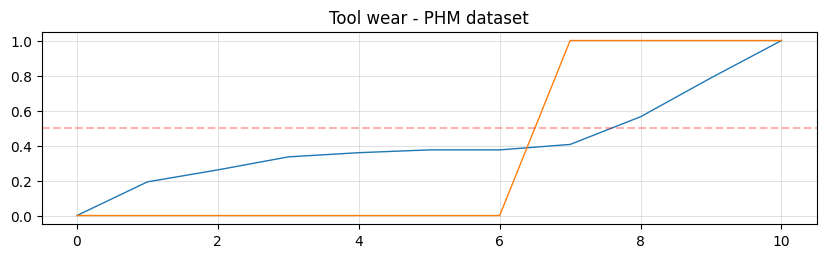

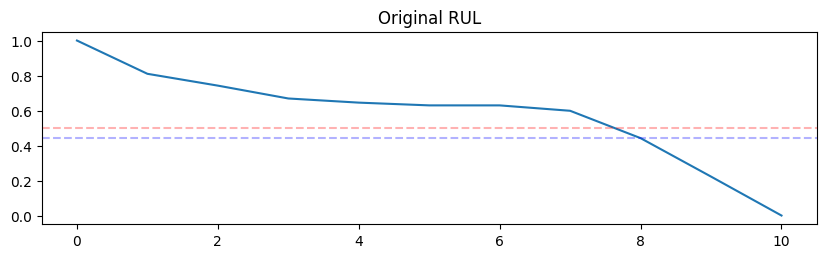

In [184]:
tool_wear, action_code, WEAR_THRESHOLD_NORMALIZED, df_train = tool_wear_data(
    env_type = ENV_TYPE, data_file=DATA_FILE, wear_threshold = WEAR_THRESHOLD,
    normalize=True, add_noise=ADD_NOISE, sampling_rate = SAMPLING_RATE)

records = len(df_train.index)
MILLING_OPERATIONS_MAX = records

plt.figure(figsize=(10, 2.5))
plt.plot(df_train['RUL'])
plt.title('Original RUL')
plt.axhline(y = rul_threshold_train, color = 'b', linestyle = '--', alpha=0.3) 
plt.axhline(y = WEAR_THRESHOLD_NORMALIZED, color = 'r', linestyle = '--', alpha=0.3) 
plt.show()

## 1. Predictive maintenance environment

In [185]:
from stable_baselines3.common.env_checker import check_env

print(f' - Model is pre-trained on NUAA W1 data.\n - Environment being created on {ENV_TYPE}.')
gym.register(
    id = 'custom/MillingToolEnv-v0',
    entry_point = MTENV,
    # entry_point = MTENV if ENV_TYPE == 'NUAA' else MillingTool_Env_PHM,
    max_episode_steps = MILLING_OPERATIONS_MAX,)

mt_env = gym.make('custom/MillingToolEnv-v0', max_records=records, env_type=ENV_TYPE, rul_threshold=rul_threshold_train)
mt_env.tool_wear_data(df_train)
# Check env. formation 
check_env(mt_env)

 - Model is pre-trained on NUAA W1 data.
 - Environment being created on PHM.

 -- V.2.0: PHM. Records 11. RUL threshold 0.442

 - Milling tool environment: Tool wear data updated: 11
Action:  0 | RUL:     1.00 | Reward:        1.000 -- CR:        1.000
Action:  1 | RUL:     1.00 | Reward:        1.000 -- CR:        1.000
Action:  1 | RUL:     0.81 | Reward:        1.000 -- CR:        2.000
Action:  0 | RUL:     0.74 | Reward:        1.000 -- CR:        3.000
Action:  1 | RUL:     0.67 | Reward:        1.000 -- CR:        4.000
Action:  0 | RUL:     0.65 | Reward:        1.000 -- CR:        5.000
Action:  1 | RUL:     0.63 | Reward:        1.000 -- CR:        6.000
Action:  1 | RUL:     0.63 | Reward:        1.000 -- CR:        7.000
Action:  0 | RUL:     0.60 | Reward:        1.000 -- CR:        8.000
*** TERMINATED: 0.44 ***
*** TERMINATED: 0.22 ***


## 2. Train the PdM Agent -or- load pre-trained model

In [186]:
if ALGO == 'PPO':
    if TENSOR_BOARD:
        expert_ppo = PPO('MlpPolicy', env=mt_env, tensorboard_log=LOG_PATH)
    else:
        expert_ppo = PPO('MlpPolicy', env=mt_env)
    
    if not PRETRAINED_MODEL:
        print(f'- Training a *NEW* {ALGO} Expert model...')
        expert_ppo.learn(EPISODES)
        print(f'- Saving Expert model in {MODEL_FILE}')
        expert_ppo.save(MODEL_FILE)
    else:
        print(f'- Loading pre-tranined {ALGO} Expert model from {MODEL_FILE}')
        expert_ppo = PPO.load(MODEL_FILE)
elif ALGO == 'A2C':
    if TENSOR_BOARD:
        expert_a2c = A2C('MlpPolicy', env=mt_env, tensorboard_log=LOG_PATH)
    else:
        expert_a2c = A2C('MlpPolicy', env=mt_env)
    
    if not PRETRAINED_MODEL:
        print(f'- Training a *NEW* {ALGO} Expert model...')
        expert_a2c.learn(EPISODES)
        print(f'- Saving Expert model in {MODEL_FILE}')
        expert_a2c.save(MODEL_FILE)
    else:
        print(f'- Loading pre-tranined {ALGO} Expert model from {MODEL_FILE}')
        expert_a2c = A2C.load(MODEL_FILE)

- Training a *NEW* A2C Expert model...
Action:  1 | RUL:     1.00 | Reward:        1.000 -- CR:        1.000
Action:  1 | RUL:     0.81 | Reward:        1.000 -- CR:        2.000
Action:  1 | RUL:     0.74 | Reward:        1.000 -- CR:        3.000
Action:  1 | RUL:     0.67 | Reward:        1.000 -- CR:        4.000
Action:  1 | RUL:     0.65 | Reward:        1.000 -- CR:        5.000
Action:  1 | RUL:     0.63 | Reward:        1.000 -- CR:        6.000
Action:  1 | RUL:     0.63 | Reward:        1.000 -- CR:        7.000
Action:  1 | RUL:     0.60 | Reward:        1.000 -- CR:        8.000
*** TERMINATED: 0.44 ***
*** TERMINATED: 0.22 ***
*** TERMINATED: 0.00 ***
Action:  0 | RUL:     1.00 | Reward:        1.000 -- CR:        1.000
Action:  0 | RUL:     0.81 | Reward:        1.000 -- CR:        2.000
Action:  0 | RUL:     0.74 | Reward:        1.000 -- CR:        3.000
Action:  0 | RUL:     0.67 | Reward:        1.000 -- CR:        4.000
Action:  0 | RUL:     0.65 | Reward:        1.

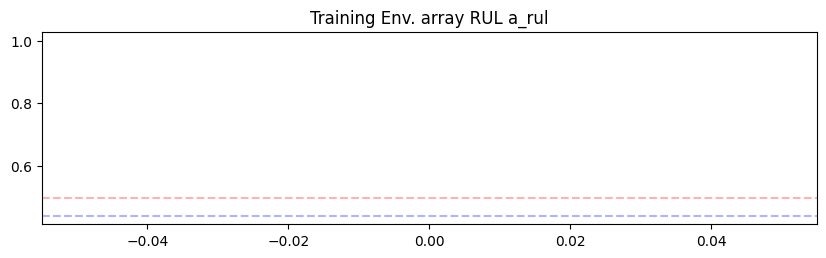

In [187]:
plt.figure(figsize=(10, 2.5))
plt.plot(mt_env.a_rul, 'b')
# plt.plot(df_train['tool_wear'], 'g')
# plt.plot(df_train['RUL'], 'r')
plt.title('Training Env. array RUL a_rul')
plt.axhline(y = rul_threshold_train, color = 'b', linestyle = '--', alpha=0.3) 
plt.axhline(y = WEAR_THRESHOLD_NORMALIZED, color = 'r', linestyle = '--', alpha=0.3) 
plt.show()

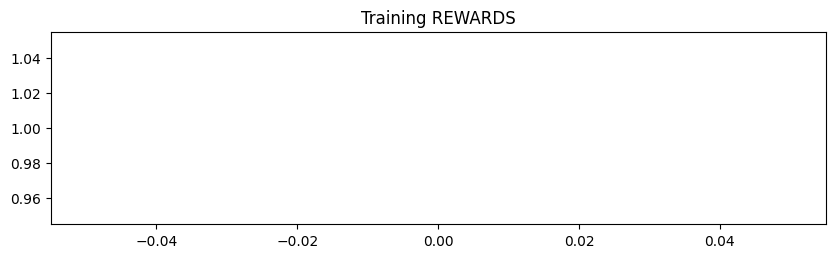

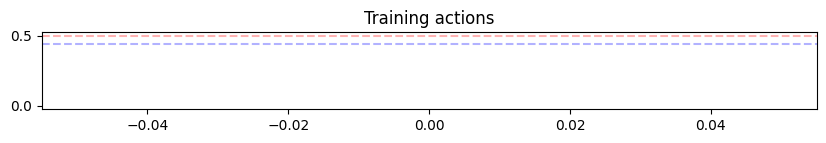

In [188]:
plt.figure(figsize=(10, 2.5))
plt.plot(mt_env.a_rewards, alpha=0.3)
plt.title('Training REWARDS')
plt.show()

plt.figure(figsize=(10, 1))
plt.plot(mt_env.a_actions, 'b', alpha=0.7)
plt.plot(mt_env.a_action_recommended, 'r', alpha=0.7)
# plt.plot(df_train['tool_wear'])
# plt.plot(df_test['RUL'])
plt.title('Training actions')
plt.axhline(y = rul_threshold_train, color = 'b', linestyle = '--', alpha=0.3) 
plt.axhline(y = WEAR_THRESHOLD_NORMALIZED, color = 'r', linestyle = '--', alpha=0.3) 
plt.show()

# EVALUATION PHASE

- Down-sampling. Input data records: 1008. Sampling rate: 10. Expected rows 101.    Down-sampled to 101 rows.


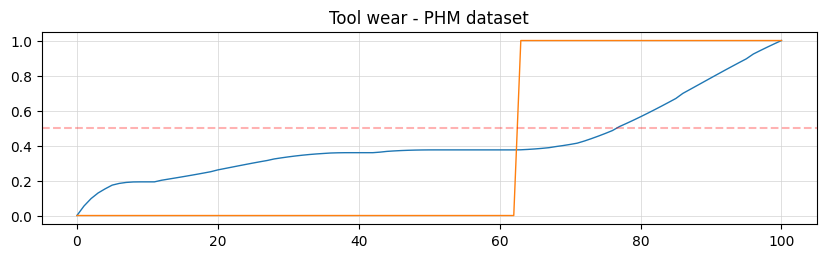

77
TRAINING: Tool-wear: 8 is 0.499, RUL: 8 is 0.442
TESTING:  Tool-wear: 77 is 0.499, RUL: 77 is 0.498


In [189]:
# ENV_TYPE = 'PHM'
TEST_DATA = datasets[EVALUATION_DATA][0]
TEST_FILE = f'{DATA_PATH}/{TEST_DATA}'
PATH = 'D:/ResearchLab/IRL/IRL_for_PdM/Data/Original_datasets/'
SAMPLING_RATE = 10
ADD_NOISE = 0

tool_wear, action_code, WEAR_THRESHOLD_NORMALIZED, df_test = tool_wear_data(
    env_type = ENV_TYPE, data_file=TEST_FILE, wear_threshold = TEST_WEAR_THRESHOLD,
    normalize=True, add_noise=ADD_NOISE, sampling_rate = SAMPLING_RATE)

n_test_records = len(df_test.index)
MILLING_OPERATIONS_MAX = n_test_records

# Compute RUL threshold for the test environment
# rul_threshold_record = int(0.95 * records)
rul_threshold_record_test = df_test.loc[df_test['tool_wear'] >= WEAR_THRESHOLD_NORMALIZED].index[0]
print(rul_threshold_record_test)
rul_threshold_test = df_test.loc[df_test.index[rul_threshold_record_test], 'RUL']
# print(f'Tool failure RUL threshold at time {rul_threshold_record_test} is {rul_threshold_test:3.3f}')

print(f'TRAINING: Tool-wear: {rul_threshold_record_train} is {WEAR_THRESHOLD_NORMALIZED:3.3f}, RUL: {rul_threshold_record_train} is {rul_threshold_train:3.3f}')
print(f'TESTING:  Tool-wear: {rul_threshold_record_test} is {WEAR_THRESHOLD_NORMALIZED:3.3f}, RUL: {rul_threshold_record_test} is {rul_threshold_test:3.3f}')

In [190]:
# gym.register(
#     id = 'custom/MillingToolEnv-v0',
#     entry_point = MillingTool_Env_NUAA if ENV_TYPE == 'NUAA' else MillingTool_Env_PHM,
#     max_episode_steps = MILLING_OPERATIONS_MAX,)

mt_test_env = gym.make('custom/MillingToolEnv-v0', max_records=n_test_records, env_type = ENV_TYPE, rul_threshold=rul_threshold_test)
mt_test_env.tool_wear_data(df_test)


 -- V.2.0: PHM. Records 101. RUL threshold 0.498

 - Milling tool environment: Tool wear data updated: 101


Action:  0 | RUL:     1.00 | Reward:        1.000 -- CR:        1.000
Action:  1 | RUL:     0.95 | Reward:        1.000 -- CR:        2.000
Action:  0 | RUL:     0.90 | Reward:        1.000 -- CR:        3.000
Action:  1 | RUL:     0.87 | Reward:        1.000 -- CR:        4.000
Action:  0 | RUL:     0.85 | Reward:        1.000 -- CR:        5.000
Action:  1 | RUL:     0.83 | Reward:        1.000 -- CR:        6.000
Action:  1 | RUL:     0.82 | Reward:        1.000 -- CR:        7.000
Action:  1 | RUL:     0.81 | Reward:        1.000 -- CR:        8.000
Action:  1 | RUL:     0.81 | Reward:        1.000 -- CR:        9.000
Action:  1 | RUL:     0.81 | Reward:        1.000 -- CR:       10.000
Action:  0 | RUL:     0.81 | Reward:        1.000 -- CR:       11.000
Action:  1 | RUL:     0.81 | Reward:        1.000 -- CR:       12.000
Action:  0 | RUL:     0.80 | Reward:        1.000 -- CR:       13.000
Action:  1 | RUL:     0.79 | Reward:        1.000 -- CR:       14.000
Action:  0 | RUL:   

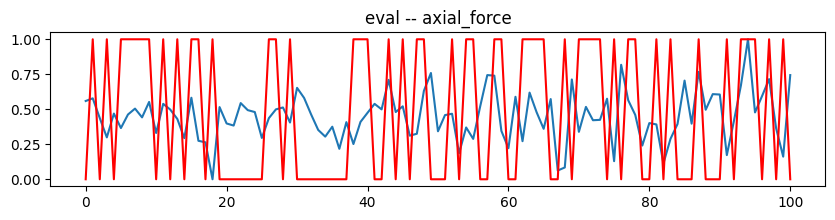

In [191]:
if ALGO == 'PPO':
    expert = expert_ppo
else:
    expert = expert_a2c
    
obsv = mt_test_env.reset()
# During reset a tuple is returned. So take the state only. When the step() is called it properly returns only the state so obsv will work
obsv = obsv[0]

eval_rewards = []
eval_action = []
eval_o = []
for i in range(n_test_records):
    action, _state = expert.predict(obsv)
    obsv, reward, done, info, _ = mt_test_env.step(action)
    eval_o.append(obsv[5])
    eval_rewards.append(reward)
    eval_action.append(action)

plt.figure(figsize=(10, 2))
plt.plot(eval_o)
plt.plot(eval_action, 'r')
plt.title('eval -- axial_force')
plt.show()